In [1]:
# Purpose:
# Import required libraries and make src/ accessible

# Source of Code and Justification:
# The project requires NumPy and Matplotlib for implementation.
# We add the parent directory to sys.path to import our custom src modules.

# Approach:
# - Add project root to Python path
# - Import standard libraries
# - Import our LIF functions from src
# - Define a directory to save figures

# What to say in Report:
# “We used NumPy and Matplotlib for simulation and visualization,
# and structured our code into reusable modules imported into the notebook.”

import sys
import os
from pathlib import Path

# Add project root (one level up) to path
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

# Define figures directory
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

# Import our LIF module
from src.lif import lif_euler_step, simulate_lif_population, lif_theoretical_fi

In [2]:
# Purpose:
# Define all global parameters for Exercise 0 using one consistent unit system.

# Source of Code and Justification:
# The project defines the LIF neuron equation and gives the parameters:
# theta = 20 mV, u_reset = -10 mV, R = 1 MOhm,
# dt = 0.5 ms, tau_m = 20 ms.
# Exercise 0.1 also specifies N = 100 neurons and T = 1000 ms.

# Approach:
# - Store voltages in mV
# - Store time in ms
# - Store currents in nA
# - Store resistance in MOhm
# With these units, R * I has units of mV because 1 MOhm * 1 nA = 1 mV.

# What to say in Report:
# “We use a custom NumPy implementation rather than Brian2, with project
# parameters and consistent units: voltage in mV, time in ms, current in nA,
# and resistance in MOhm.”

# Neuron parameters
N = 100
theta = 20.0       # mV
u_reset = -10.0    # mV
R = 1.0            # MOhm
dt = 0.5           # ms
tau_m = 20.0       # ms

# Exercise 0.1 input parameters
T = 1000.0         # ms
I0 = 20.0          # nA
omega = 10.0       # rad/s

# Background input parameters
n_bg = 25.0        # mean number of background events per time step
bg_scale = 1.0     # nA per background event

In [3]:
# Purpose:
# Create the oscillating external input and random initial membrane potentials
# for Exercise 0.1.

# Source of Code and Justification:
# Exercise 0.1 specifies N = 100 unconnected neurons, T = 1000 ms,
# I_i(t) = I0(1 + sin(ωt)), with I0 = 20 nA and ω = 10 rad/s.
# It also specifies random initial conditions:
# u_i(0) ~ Uniform(u_reset, theta).

# Approach:
# - Build a time vector in ms.
# - Convert time from ms to seconds before evaluating sin(ωt),
#   because ω is given in rad/s.
# - Use the same external input for all neurons.
# - Initialize membrane potentials uniformly between u_reset and theta.

# What to say in Report:
# “For Exercise 0.1, all neurons received the same slowly oscillating external
# current. Time was converted from milliseconds to seconds inside the sine
# because the angular frequency is given in rad/s. Initial voltages were sampled
# uniformly between reset and threshold.”

# Time vector
time_ms = np.arange(0.0, T, dt)
time_s = time_ms / 1000.0

# External input: I_i(t) = I0(1 + sin(omega t))
I_ext_0_1 = I0 * (1.0 + np.sin(omega * time_s))

# Same input to all neurons
I_ext_0_1 = I_ext_0_1[:, None] * np.ones((1, N))

# Random initial membrane potentials
rng = np.random.default_rng(seed=0)
u0 = rng.uniform(u_reset, theta, size=N)

print("Input shape:", I_ext_0_1.shape)
print("Initial voltage shape:", u0.shape)
print("Simulation steps:", len(time_ms))

Input shape: (2000, 100)
Initial voltage shape: (100,)
Simulation steps: 2000


In [4]:
# Purpose:
# Simulate the dynamics of the LIF population under oscillating input
# with stochastic background input (Exercise 0.1).

# Source of Code and Justification:
# The project specifies that all neurons receive stochastic background input
# modeled as a Poisson process with mean n_bg = 25 per time step.
# The total input is I_i(t) = I_ext(t) + I_bg(t).
# This corresponds to noisy spike arrivals from external neurons,
# as discussed in the lecture on stochastic input.

# Approach:
# - Use the simulate_lif_population function
# - Provide oscillating external input
# - Add Poisson background input at each time step
# - Simulate for the full duration T = 1000 ms
# - Store membrane potentials (U) and spike trains (S)

# What to say in Report:
# “We included stochastic background input modeled as a Poisson process
# to mimic random spike arrivals. This introduces variability in neuron
# responses and prevents full synchronization of the population.”

U, S = simulate_lif_population(
    I_ext=I_ext_0_1,
    u0=u0,
    dt=dt,
    tau_m=tau_m,
    R=R,
    theta=theta,
    u_reset=u_reset,
    n_bg=n_bg,
    bg_scale=bg_scale,
    seed=0
)

print("Voltage shape:", U.shape)
print("Spike train shape:", S.shape)

Voltage shape: (2000, 100)
Spike train shape: (2000, 100)


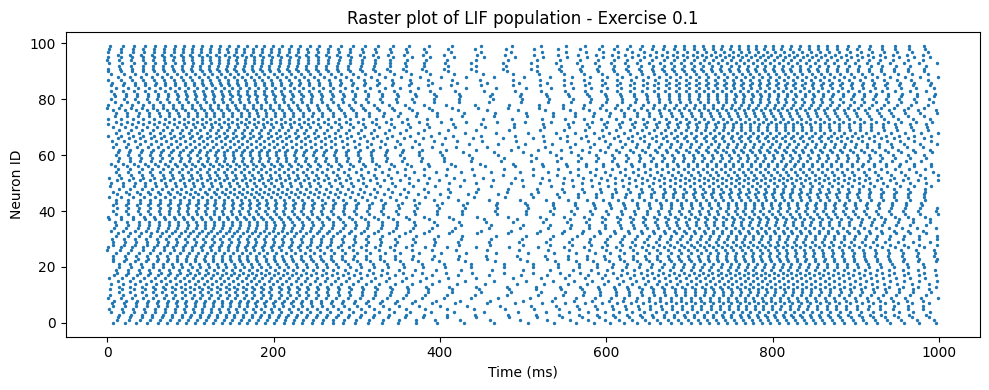

In [5]:
# Purpose:
# Create a raster plot of all spike times for the N = 100 neurons.

# Source of Code and Justification:
# Exercise 0.1 asks for a raster plot: a scatter plot where each spike is a dot,
# with time on the x-axis and neuron id on the y-axis.
# This follows the spike-train idea from the LIF model, where spikes are treated
# as discrete events rather than continuous voltage waveforms.

# Approach:
# - Find all entries where S > 0.
# - Convert spike time-step indices into physical time in ms.
# - Plot spike time against neuron id using plt.scatter.

# What to say in Report:
# “The raster plot represents spikes as discrete events. Each dot corresponds
# to one neuron crossing threshold at a given time step.”
spike_step_indices, neuron_ids = np.where(S > 0)

spike_times_ms = time_ms[spike_step_indices]

plt.figure(figsize=(10, 4))
plt.scatter(spike_times_ms, neuron_ids, s=2)
plt.xlabel("Time (ms)")
plt.ylabel("Neuron ID")
plt.title("Raster plot of LIF population - Exercise 0.1")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "ex0_1_raster.png", dpi=300)
plt.show()

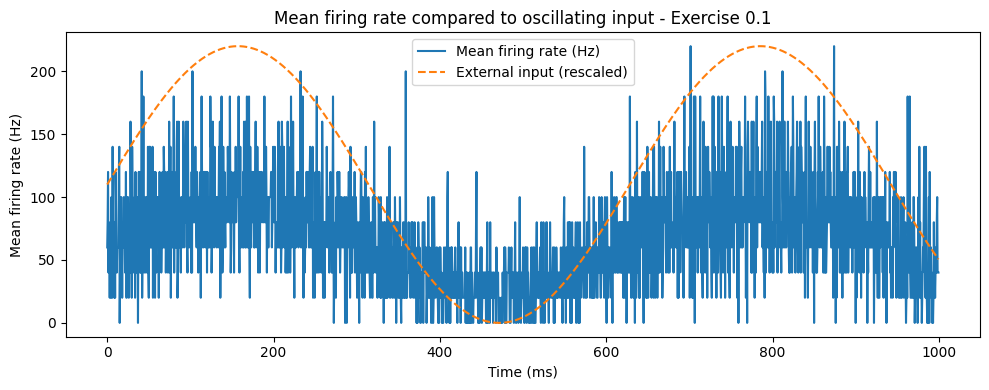

In [6]:
# Purpose:
# Compute and plot the mean population firing rate over time, and compare it
# to the oscillating external input.

# Source of Code and Justification:
# Exercise 0.1 asks us to plot the mean firing rate over time and compare it
# to the external input. The project defines the discrete spike train as
# s_i(t_k) = 1/Δt when a neuron spikes and zero otherwise.
# Therefore, the population activity is A(t) = (1/N) sum_i s_i(t).

# Approach:
# - Average the spike train matrix S across neurons.
# - Convert from spikes/ms/neuron to Hz by multiplying by 1000.
# - Plot the firing rate together with a rescaled version of the external input
#   so their time courses can be visually compared.

# What to say in Report:
# “The population firing rate follows the oscillating input, but with noise and
# smoothing due to stochastic background input and membrane integration.”

# Mean firing rate in Hz
rate_hz = S.mean(axis=1) * 1000.0

# Rescale input for visual comparison with firing rate
input_trace = I_ext_0_1[:, 0]
input_scaled = input_trace / input_trace.max() * rate_hz.max()

plt.figure(figsize=(10, 4))
plt.plot(time_ms, rate_hz, label="Mean firing rate (Hz)")
plt.plot(time_ms, input_scaled, "--", label="External input (rescaled)")
plt.xlabel("Time (ms)")
plt.ylabel("Mean firing rate (Hz)")
plt.title("Mean firing rate compared to oscillating input - Exercise 0.1")
plt.legend()
plt.tight_layout()

plt.savefig(FIGURES_DIR / "ex0_1_rate_vs_input.png", dpi=300)
plt.show()

In [7]:
# Purpose:
# Simulate the empirical f-I curve for a population of N = 100 LIF neurons
# receiving stochastic background input.

# Source of Code and Justification:
# Exercise 0.2 asks us to sweep constant external currents from -10 nA to
# 50 nA in steps of 5 nA. For each current, the network should be simulated
# for T = 100 ms, and the mean firing rate should be averaged over the last
# 50 ms. The project also specifies that stochastic background input is included
# with n_bg = 25.

# Approach:
# - Create a list of constant external currents.
# - For each current I0, simulate the population for 100 ms.
# - Compute the population firing rate over time.
# - Average only over the last 50 ms.
# - Store one mean firing rate per current value.

# What to say in Report:
# “For the empirical f-I curve, we simulated the population response to constant
# external currents and measured the mean firing rate during the last 50 ms,
# excluding the initial transient.”

from tqdm import tqdm

I_values = np.arange(-10.0, 55.0, 5.0)

T_fi = 100.0
time_fi = np.arange(0.0, T_fi, dt)
n_steps_fi = len(time_fi)

avg_start = 50.0
avg_start_idx = int(avg_start / dt)

empirical_rates = []

rng = np.random.default_rng(seed=1)

for I_const in tqdm(I_values):
    I_ext_const = np.full((n_steps_fi, N), I_const)

    u0_fi = rng.uniform(u_reset, theta, size=N)

    U_fi, S_fi = simulate_lif_population(
        I_ext=I_ext_const,
        u0=u0_fi,
        dt=dt,
        tau_m=tau_m,
        R=R,
        theta=theta,
        u_reset=u_reset,
        n_bg=n_bg,
        bg_scale=bg_scale,
        seed=rng.integers(0, 2**32 - 1),
    )

    rate_fi_hz = S_fi.mean(axis=1) * 1000.0
    empirical_rates.append(rate_fi_hz[avg_start_idx:].mean())

empirical_rates = np.array(empirical_rates)

print("I values:", I_values)
print("Empirical rates:", empirical_rates)

  0%|          | 0/13 [00:00<?, ?it/s]

100%|██████████| 13/13 [00:00<00:00, 23.05it/s]

I values: [-10.  -5.   0.   5.  10.  15.  20.  25.  30.  35.  40.  45.  50.]
Empirical rates: [  0.   13.   24.6  34.   44.6  53.8  62.4  73.   80.2  90.6  95.8 105.8
 113.2]


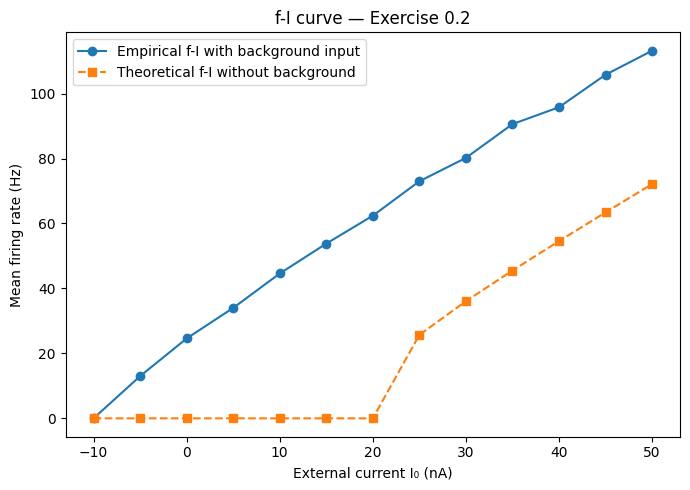

In [8]:
# Purpose:
# Plot the empirical f-I curve together with the theoretical deterministic
# LIF f-I curve.

# Source of Code and Justification:
# Exercise 0.2 asks us to plot the simulated f-I curve and, in the same plot,
# the theoretical f-I curve for LIF neurons without background input.
# The week 1 notebook's f-I curve section provides the same idea: simulate responses
# to constant currents, count spikes, and convert spike counts to firing rates.

# Approach:
# - Compute the theoretical f-I curve using the analytic LIF formula.
# - Plot empirical firing rates from the stochastic population simulation.
# - Plot theoretical firing rates from the deterministic single-neuron formula.
# - Compare the curves visually.

# What to say in Report:
# “The empirical curve differs from the theoretical deterministic curve because
# the simulation includes stochastic background input. This allows neurons to
# fire even below the deterministic threshold and introduces variability in the
# measured firing rates.”

theoretical_rates = lif_theoretical_fi(
    I_values,
    tau_m=tau_m,
    R=R,
    theta=theta,
    u_reset=u_reset,
)

plt.figure(figsize=(7, 5))
plt.plot(I_values, empirical_rates, "o-", label="Empirical f-I with background input")
plt.plot(I_values, theoretical_rates, "s--", label="Theoretical f-I without background")
plt.xlabel("External current I₀ (nA)")
plt.ylabel("Mean firing rate (Hz)")
plt.title("f-I curve — Exercise 0.2")
plt.legend()
plt.tight_layout()

plt.savefig(FIGURES_DIR / "ex0_2_fi_curve.png", dpi=300)
plt.show()